<a href="https://colab.research.google.com/github/vikasverma9721/Machine-Learning-Models/blob/main/Linear_Regression_House_Price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df2 = '/content/drive/MyDrive/Dataset/House_Price_Prediction_dataset.csv'

In [ ]:
df = pd.read_csv(df2)

In [ ]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
4595,False
4596,False
4597,False
4598,False


In [ ]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


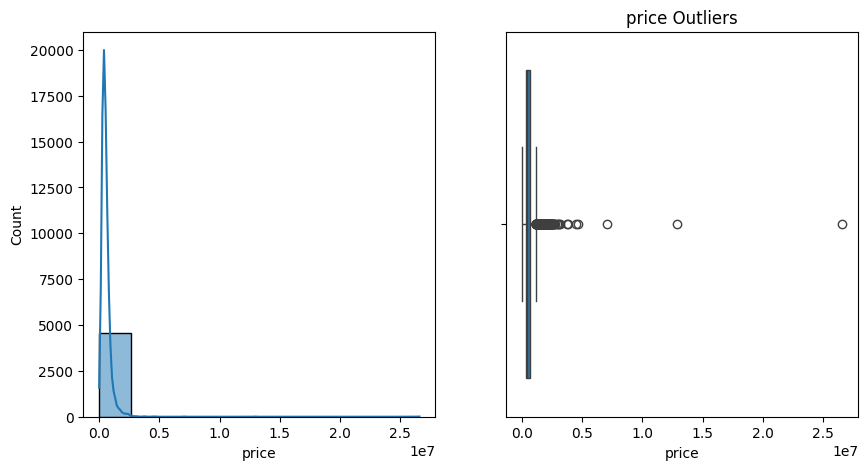

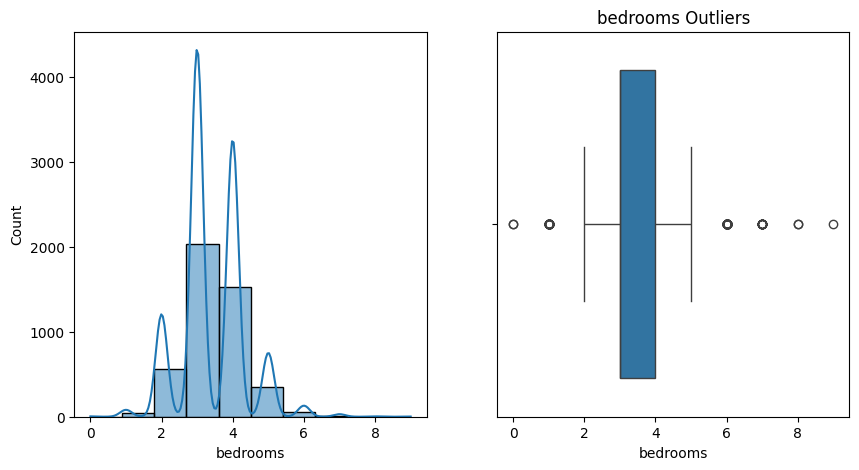

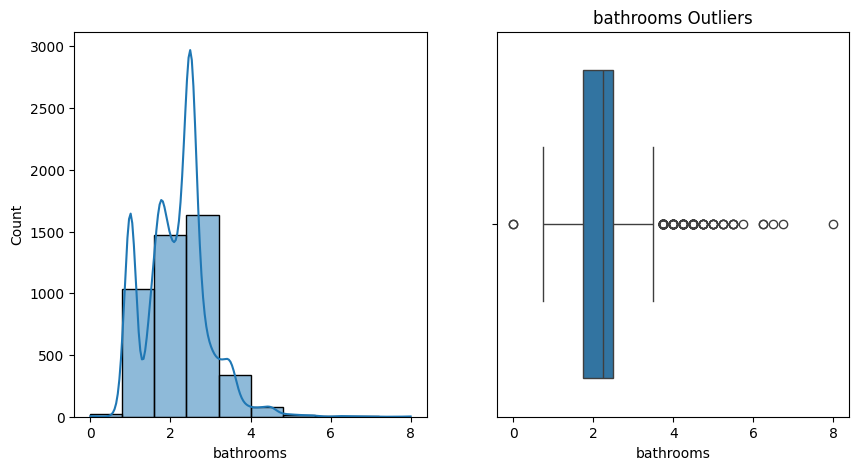

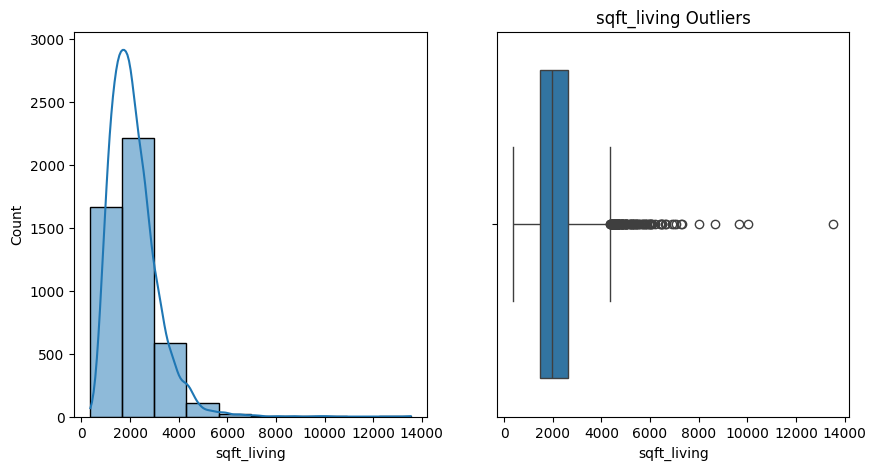

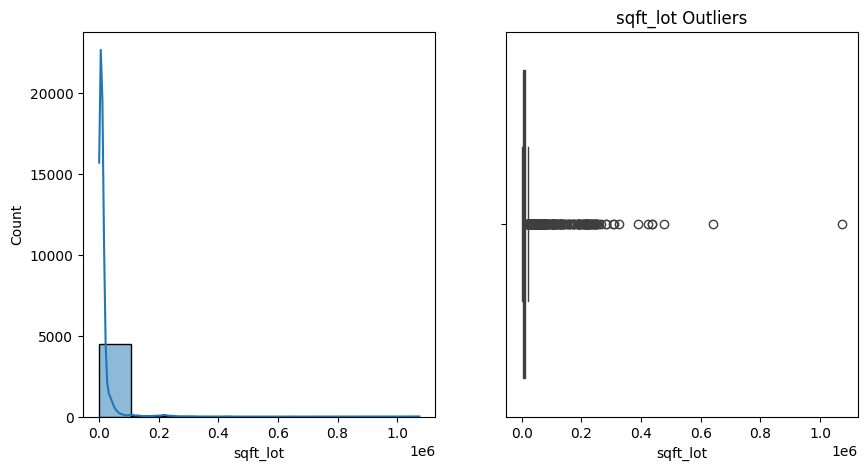

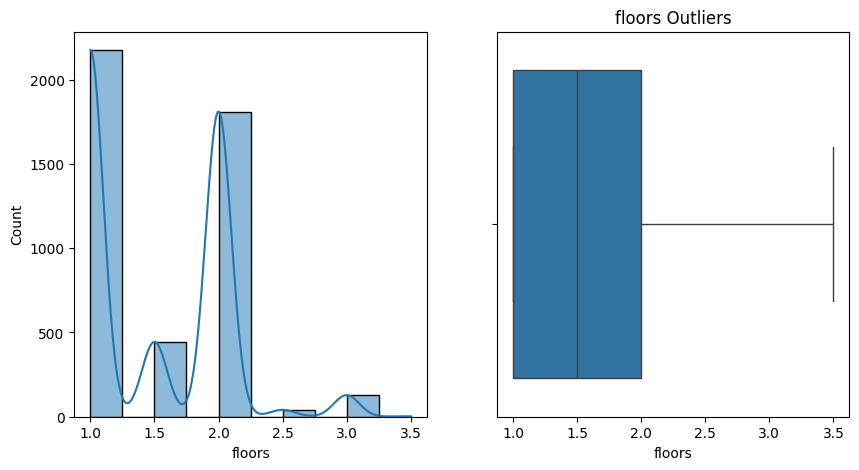

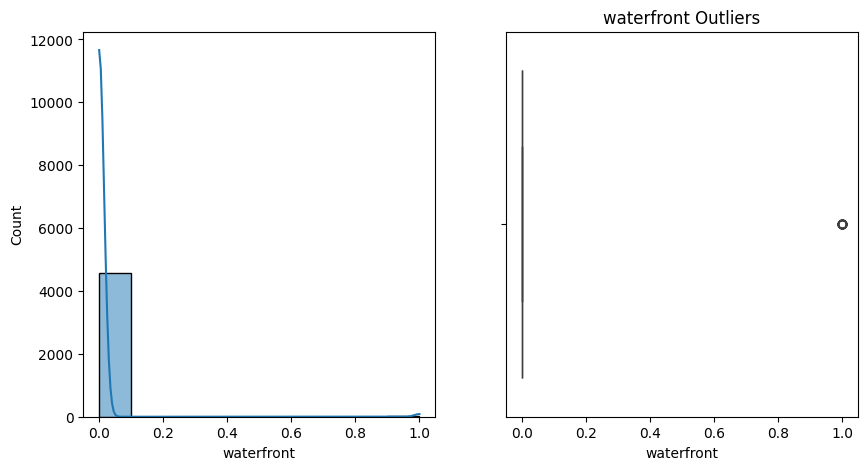

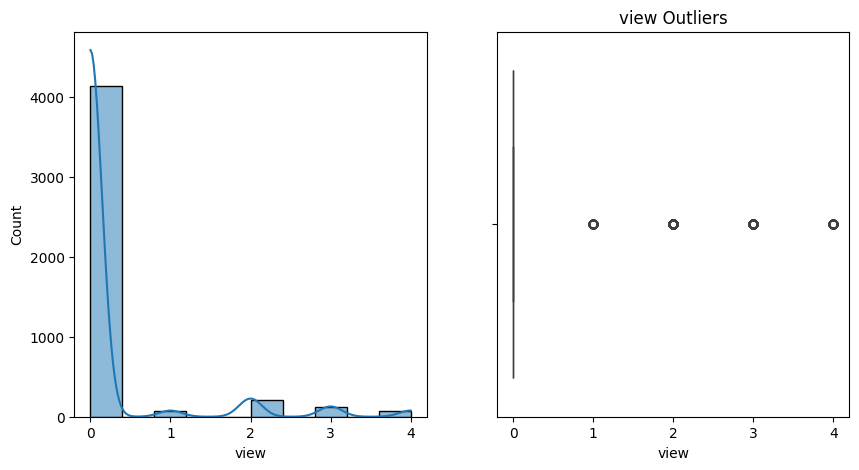

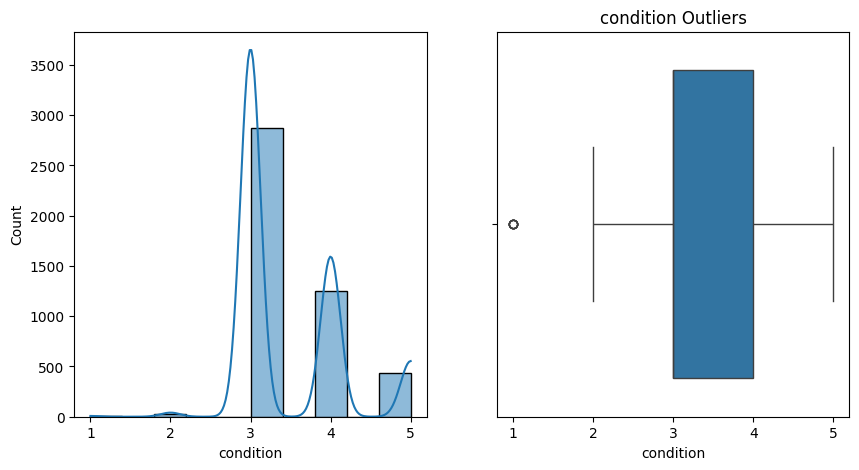

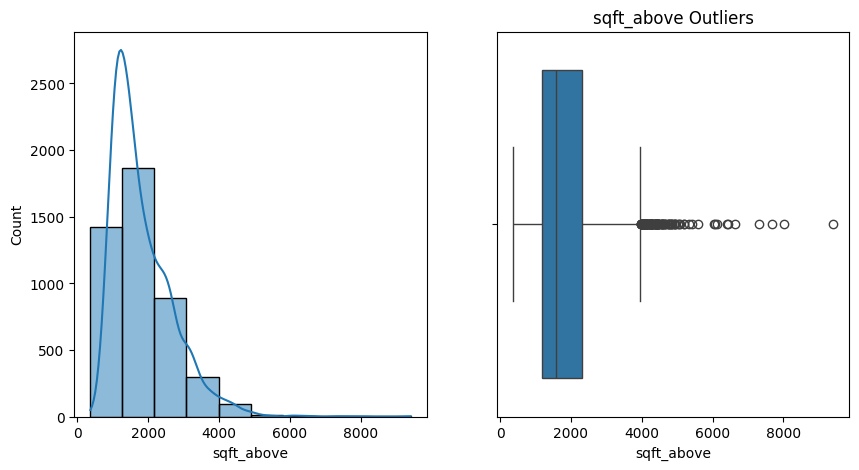

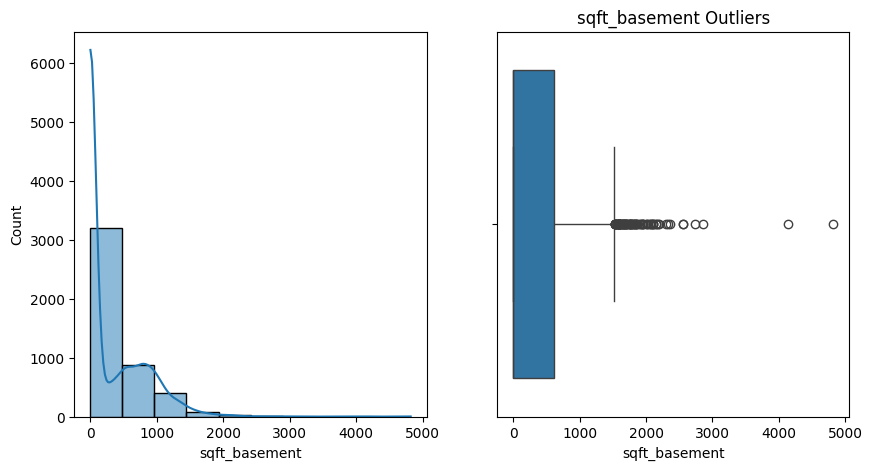

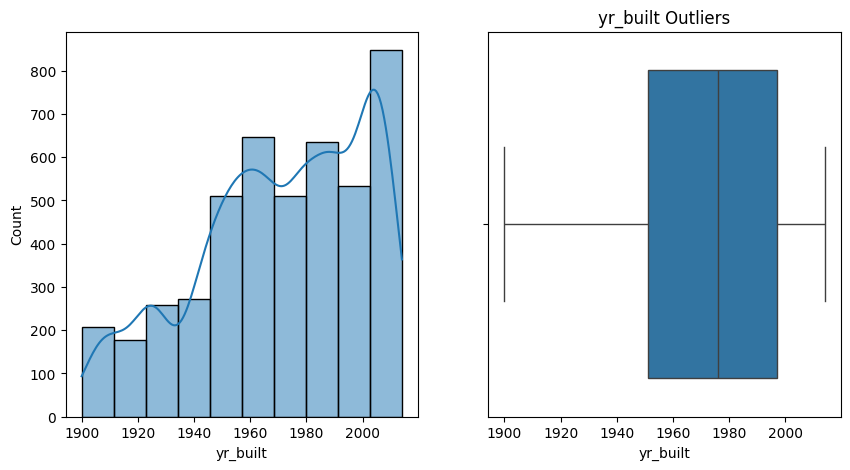

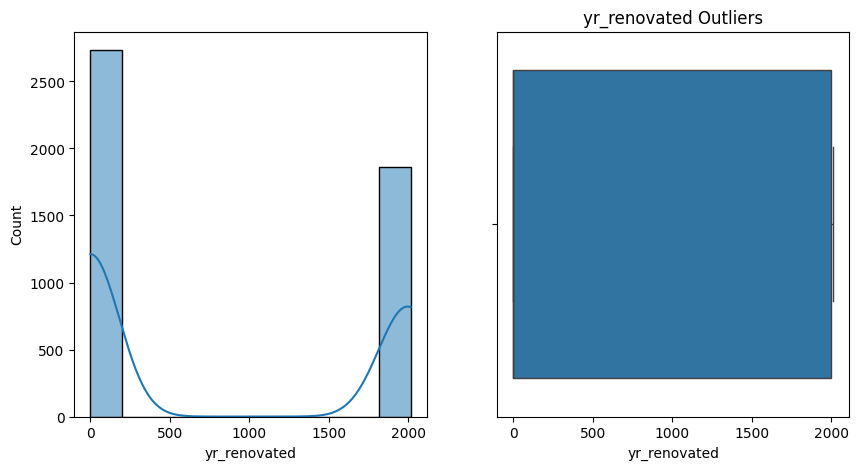

In [ ]:
columns = df[['price',	'bedrooms',	'bathrooms',	'sqft_living',	'sqft_lot',	'floors',	'waterfront',	'view',	'condition',	'sqft_above',	'sqft_basement',	'yr_built',	'yr_renovated']].copy()
for column in columns:
  plt.figure(figsize = (10,5))
  plt.subplot(1,2,1)
  sns.histplot(df[column], bins = 10, kde = True)

  plt.subplot(1,2,2)
  sns.boxplot(x = df[column])
  plt.title(f'{column} Outliers')
  plt.show()

***Remove Outliers from IQR Method in the price column.***

In [ ]:
percentile25 = columns['price'].quantile(0.25)
percentile75 = columns['price'].quantile(0.75)
print("Percentile25 =", percentile25)
print("Percentile75 =", percentile75)

Percentile25 = 322875.0
Percentile75 = 654962.5


In [ ]:
iqr = percentile75 - percentile25
print("IQR =", iqr)

IQR = 332087.5


In [ ]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Upper Limit =", upper_limit)
print("Lower Limit =", lower_limit)

Upper Limit = 1153093.75
Lower Limit = -175256.25


***Finding Outliers.***

In [ ]:
columns[columns['price'] > upper_limit]

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
1,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0
11,1.400000e+06,4.0,2.50,2920,4000,1.5,0,0,5,1910,1010,1909,1988
14,1.200000e+06,5.0,2.75,2910,9480,1.5,0,0,3,2910,0,1939,1969
99,1.395000e+06,5.0,3.50,4010,8510,2.0,0,1,5,2850,1160,1971,0
122,2.280000e+06,7.0,8.00,13540,307752,3.0,0,4,3,9410,4130,1999,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4348,2.199900e+06,4.0,1.50,1120,5427,1.0,0,0,3,1120,0,1969,2014
4350,2.659000e+07,3.0,2.00,1180,7793,1.0,0,0,4,1180,0,1992,0
4465,2.560498e+06,3.0,2.50,1710,1664,2.0,0,0,5,1300,410,2003,0
4467,1.337044e+06,4.0,3.50,4280,9583,2.0,0,0,3,4280,0,2005,0


In [ ]:
columns[columns['price'] < lower_limit]

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated


***Capping.***

In [ ]:
new_df = columns.copy()

In [ ]:
columns.shape

(4600, 13)

In [ ]:
new_df['price'] = np.where(
    new_df['price'] > upper_limit,
    upper_limit,
    np.where(
        new_df['price'] < lower_limit,
        lower_limit,
        new_df['price']
    )
)

<function matplotlib.pyplot.show(close=None, block=None)>

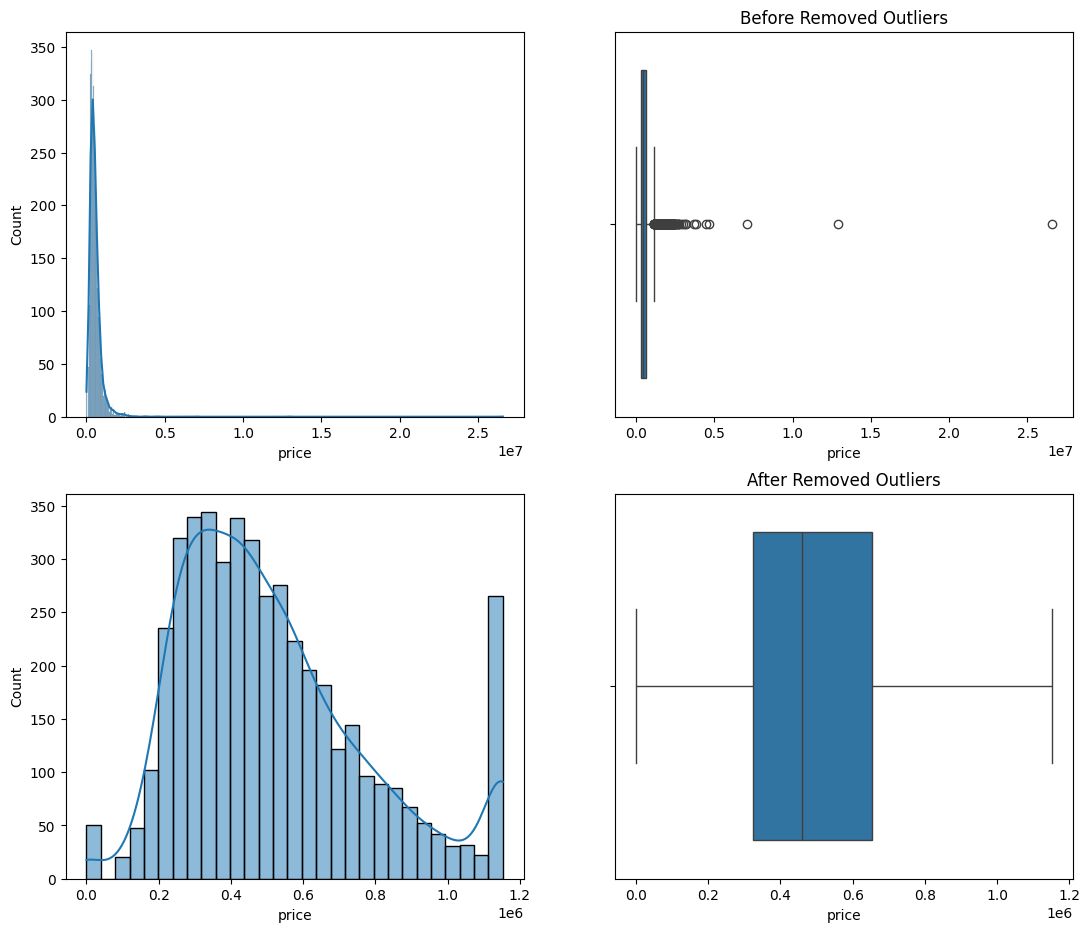

In [ ]:
plt.figure(figsize = (13,11))
plt.subplot(2,2,1)
sns.histplot(columns['price'], kde = True)

plt.subplot(2,2,2)
sns.boxplot(x = columns['price'])
plt.title("Before Removed Outliers")

plt.subplot(2,2,3)
sns.histplot(new_df['price'], kde = True)

plt.subplot(2,2,4)
sns.boxplot(x = new_df['price'])
plt.title("After Removed Outliers")
plt.show